# Plots for the paper

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pylab as pylab

size=24
params = {'legend.fontsize': size,
          'figure.figsize': (15, 5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# get minima structure configurations
from flonacomldft.utils.silver_isomers_utils import get_molecule_isomer_minima
from flonacomldft.utils.plots import plot_energy_surface
from ase.visualize.plot import plot_atoms
from flonacomldft.internal_coordinates import Coordinates_mapping

ag6_is0 = get_molecule_isomer_minima(name="is0")
ag6_is1 = get_molecule_isomer_minima(name="is1")

ag6_is0.center()
ag6_is1.center()

ag6_is0.translate([4, 0, 0])
ag6_is1.translate([11, 7, 7])

In [3]:
# load adaptive simulations
from flonacomldft.utils.io_utils import load_pickle_file
from flonacomldft.utils.plots import set_plot_sequential_data
from flonacomldft.utils.diagnostics import avg_windows

# 300 K results
# path = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/1-adaptive/results_2"
# simulations = ["results_adaptive_is0_25072550/adaptive_sampling_is0_25072550.pkl",
#               "results_adaptive_is1_25072551/adaptive_sampling_is1_25072551.pkl"]

# 350 K results
path = "/mnt/home/amolina/ceph/adaptive-350/adaptive-dft"
adaptive_dft_path = ['1-adaptive/results_adaptive_is0_28685740/adaptive_sampling_is0_28685740.pkl',
                    '1-adaptive/results_adaptive_is1_28685741/adaptive_sampling_is1_28685741.pkl']

adaptive_mlp_path = ['2-adaptive-mlp/results_adaptive_is0_28706672/adaptive_sampling_is0_28706672.pkl',
                    '2-adaptive-mlp/results_adaptive_is1_28707820/adaptive_sampling_is1_28707820.pkl']

adaptives_dft = {i: load_pickle_file(adaptive_dft_path[i], path) for i in range(0, 2)}
adaptives_mlp = {i: load_pickle_file(adaptive_mlp_path[i], path) for i in range(0, 2)}

In [4]:
#import pandas as pd
#
#part_ratios = pd.read_csv("/mnt/home/amolina/ceph/ADAPTIVE-DFT/2-multimodal-sampling/results_2/part_ratios_adaptive.csv")
#part_ratios.keys()

In [5]:
# simulation files
mcmc_paths = ['5-multimodal/results_multimodal_sampling_mixture_29096190/mixture_mcmc_dic_29096190.pkl',
             '6-multimodal-mlp/results_multimodal_sampling_mixture_29134160/mixture_mcmc_dic_29134160.pkl',
             '6-multimodal-mlp/results_multimodal_sampling_mixture_29134161/mixture_mcmc_dic_29134161.pkl']

# load mcmc results
keys = ['DFT-DFT', 'DFT-MLP', 'MLP-MLP']
color_keys = dict(zip(keys, ['blue', 'orange', 'red']))
mcmcs = {key: load_pickle_file(mcmc_path, path) for mcmc_path, key in zip(mcmc_paths, keys)}

## Adaptive one isomer.

In [6]:
keys = ['DFT only', 'DFT+NP']
color_keys = dict(zip(keys, ['blue', 'orange']))
adaptives_is0 = {key: load_pickle_file(adaptive, path) for key, adaptive in zip(keys, [adaptive_dft_path[0], adaptive_mlp_path[0]])}

In [7]:
accs = {key: torch.cat(adaptives_is0[key]['accs']).mean(axis=1) for key in keys}

In [8]:
us = {key: torch.cat(adaptives_is0[key]['us']) for key in keys}
energies = {key: us[key].flatten().detach().numpy() for key in keys}
xs = {key: torch.cat(adaptives_is0[key]['xs']) for key in keys}

In [9]:
def cvs_from_adaptive(adaptive):

    coord_mapping = Coordinates_mapping(etype='dft')

    xs = torch.cat(adaptive['xs']).detach()

    xs_flatten = xs.reshape(-1, 12)

    isomers_mask = torch.cat(adaptive['isomers']).reshape(-1, 1)

    xs_is0 = []

    for isomer, x in zip(isomers_mask, xs_flatten):

        if (isomer[0]==0).item():
            xs_is0.append(x)

    xs_is0 = torch.stack(xs_is0) 

    cvs_is0 = coord_mapping.get_collective_variables_from_real_centered(xs_is0, isomer=0)

    return cvs_is0

In [10]:
cvs = {key: cvs_from_adaptive(adaptives_is0[key]) for key in adaptives_is0.keys()}

/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51

In [11]:
cvs

{'DFT only': tensor([[10.1974,  2.4536],
         [ 9.9752,  2.4721],
         [10.3937,  2.4362],
         ...,
         [10.9652,  2.3445],
         [10.2606,  2.4061],
         [ 9.9282,  2.4467]], dtype=torch.float64),
 'DFT+NP': tensor([[ 9.5028,  2.4838],
         [10.1138,  2.4527],
         [10.6965,  2.4181],
         ...,
         [ 9.6750,  2.4715],
         [ 9.9726,  2.4493],
         [ 9.3872,  2.4341]], dtype=torch.float64)}

In [12]:
flow_models = {key: adaptives_is0[key]["dict_flows_training"][-2][0]["model"] for key in adaptives_is0.keys()}

nlls = {key: flow_models[key].nll(xs[key][:, 12]).detach().numpy() for key in adaptives_is0.keys()}

Text(0.5, 0, 'MCMC steps')

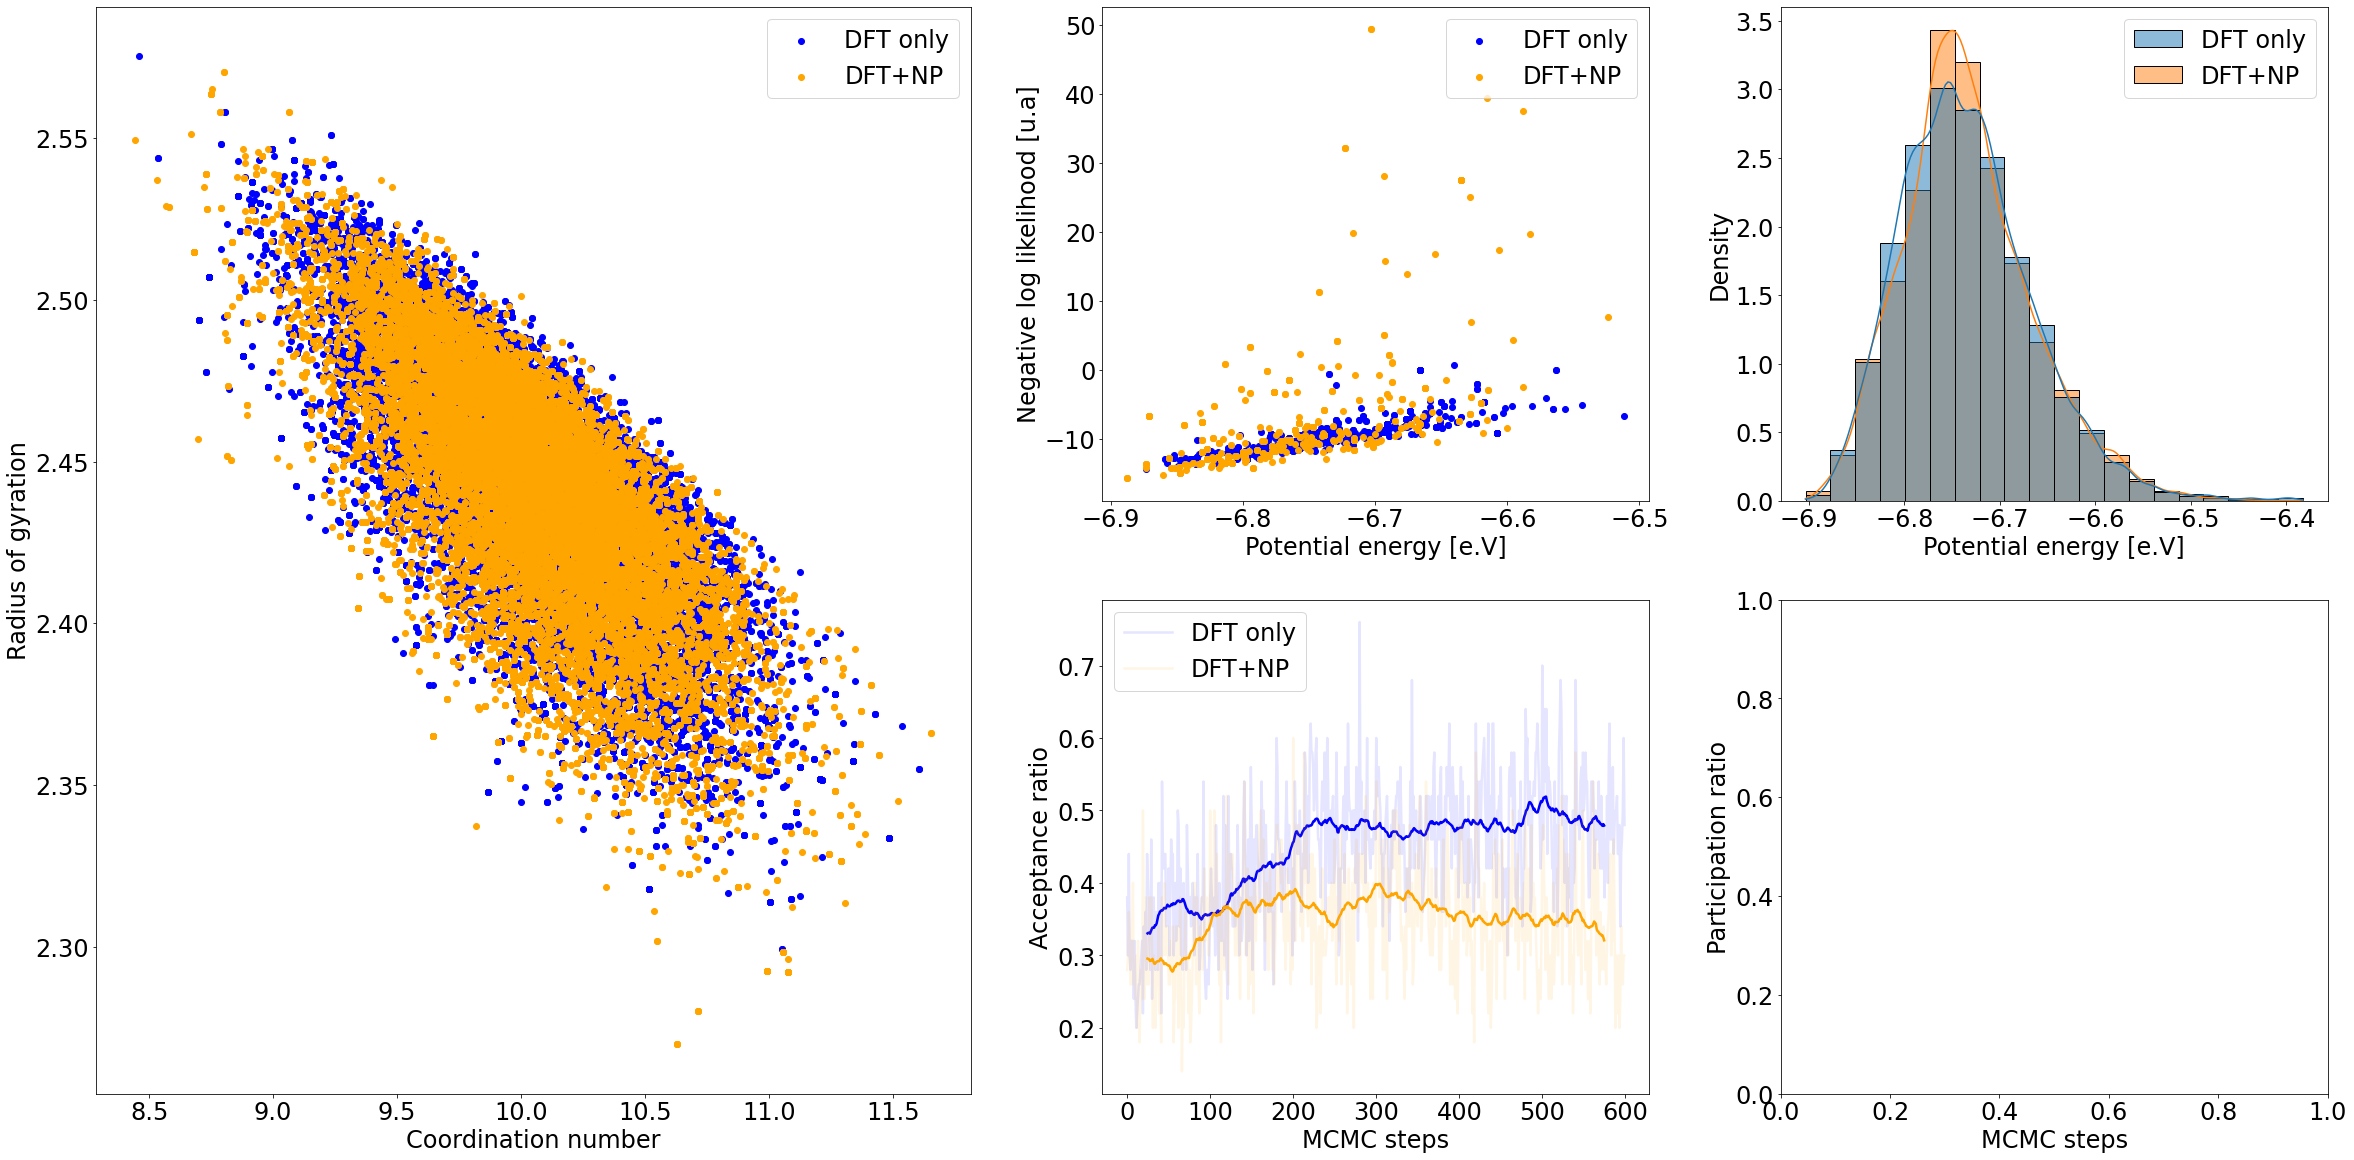

In [13]:
fig, axs = plt.subplots(ncols=3, nrows=2, figsize=(40, 20), gridspec_kw={'width_ratios': [1.6, 1, 1]})
gs = axs[0, 0].get_gridspec()
# remove the underlying axes
for ax in axs[0:, 0]:
    ax.remove()
    
    
axbig = fig.add_subplot(gs[0:, :1])
#axbig.annotate('Big Axes \nGridSpec[1:, -1]', (0.1, 0.5),
               #xycoords='axes fraction', va='center')

#plot_energy_surface(fig=fig, ax=axbig)
for key in keys:
    axbig.scatter(cvs[key][:, 0].detach().numpy(), cvs[key][:, 1].detach().numpy(), c=color_keys[key], label=key)

axbig.set_xlabel('Coordination number')
axbig.set_ylabel('Radius of gyration')

axbig.legend()
#plot_atoms(ag6_is0, ax=axbig)

#====

for key in keys:
    axs[0][1].scatter(us[key][:, 12].detach().numpy(), nlls[key], c=color_keys[key], label=key)

axs[0][1].set_ylabel("Negative log likelihood [u.a]")
axs[0][1].set_xlabel("Potential energy [e.V]")
axs[0][1].legend()

#====

sns.histplot(energies, ax=axs[0][2], kde=True, stat="density", color=color_keys, bins=20)
axs[0][2].set_xlabel("Potential energy [e.V]")

#====

for key in accs.keys():
    set_plot_sequential_data(accs[key], 
                             avg=True, 
                             window_size=50, 
                             color=color_keys[key], 
                             ax=axs[1][1], 
                             linewidth=2.5, 
                             alpha=0.1,
                             label=key)

axs[1][1].legend()
axs[1][1].set_ylabel("Acceptance ratio")
axs[1][1].set_xlabel("MCMC steps")

#====

axs[1][2].set_ylabel("Participation ratio")
axs[1][2].set_xlabel("MCMC steps")

#axs[1][2].plot(range(0, 30*20, 20), part_ratios['is0_25072550'], label="is0")
#axs[1][2].plot(range(0, 30*20, 20), part_ratios['is1_25072551'], label="is1")